# Geeignete Modelle finden

In diesem Notbook werden mehrere Modelle ausprobiert um zu überprüfen welche die besten Vorhersagen auf diesem Datenset tätigen.

## 1. Module importieren und Daten einlesen

In [1]:
# Import what we need

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
# Read the previously splitted Train and Test data
# Features and target were also separated previously

features_train = pd.read_csv('../data/processed/features_train.csv', index_col=0)
features_test = pd.read_csv('../data/processed/features_test.csv', index_col=0)
target_train = pd.read_csv('../data/processed/target_train.csv', index_col=0)
target_test = pd.read_csv('../data/processed/target_test.csv', index_col=0)

# Targets have to be pandas series
target_train = target_train['poisonous']
target_test = target_test['poisonous']

# Load the info data frame as well
side_info = pd.read_csv('../data/processed/side_info.csv', index_col=0)
display(side_info)

,name,role,type,description,nr_of_uniques
0,poisonous,Target,Binary,"0=poisonous, 1=edible",2
1,cap-shape,Feature,Categorical,"bell=b,conical=c,convex=x,flat=f, knobbed=k,su...",6
2,cap-surface,Feature,Categorical,"fibrous=f,grooves=g,scaly=y,smooth=s",4
3,cap-color,Feature,Categorical,"brown=n,buff=b,cinnamon=c,gray=g,green=r, pink...",10
4,bruises,Feature,Binary,"bruises=t,no=f",2
5,odor,Feature,Categorical,"almond=a,anise=l,creosote=c,fishy=y,foul=f, mu...",9
6,gill-attachment,Feature,Categorical,"attached=a,descending=d,free=f,notched=n",2
7,gill-spacing,Feature,Categorical,"close=c,crowded=w,distant=d",2
8,gill-size,Feature,Categorical,"broad=b,narrow=n",2
9,gill-color,Feature,Categorical,"black=k,brown=n,buff=b,chocolate=h,gray=g, gre...",12


## 2. Modelle und Pipeline

Für verschiedene Modelle Pipelines aufbauen und Testen.

Die Vorbereitung der Features mittels ColumnTransformer ist für alle Modelle gleich. Daher wird dieser nur einmal erstellt.

In [3]:
# Differentiate between category cols (for OHE) and binary cols (for OE)
cat_cols = []
bin_cols = []

# go through the side_info
# ignore the first row since it is the target
for i in range(1, side_info.shape[0]):
    si_row = side_info.iloc[i]
    if si_row['type'] == 'Categorical':
        cat_cols.append(si_row['name'])
    elif si_row['type'] == 'Binary':
        bin_cols.append(si_row['name'])
    else:
        print('Something unexpected happened. Check:', si_row['name'])

# create the two encoders we need
oe = OrdinalEncoder()
ohe = OneHotEncoder(sparse_output=False,
                    handle_unknown='warn')

# create the ColumnTransformer with both encoders
encoder = ColumnTransformer([('oe', oe, bin_cols), 
                            ('ohe', ohe, cat_cols)],
                            remainder='drop')

# Although it will be used in a pipeline later,
# here we check how it applies to the training features
transformed_features = encoder.fit_transform(features_train)
feature_names = []
for name, transformer, columns in encoder.transformers_:
    if name == 'oe':
        cnames = columns
    elif name == 'ohe':
        cnames = transformer.get_feature_names_out(columns)
    else:
        print('Error: Check if the encoder was manipulated')
        cnames = -1
    feature_names.extend(cnames)

transformed_features = pd.DataFrame(transformed_features, columns=feature_names)
display(transformed_features.head(10))

,bruises,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 2.1. Logistic Regression

Das erste Modell, dass wir untersuchen ist die Logistische Regression.
Wir starten mit einer Logistischen Regression ohne Regularisierung.

<Axes: >

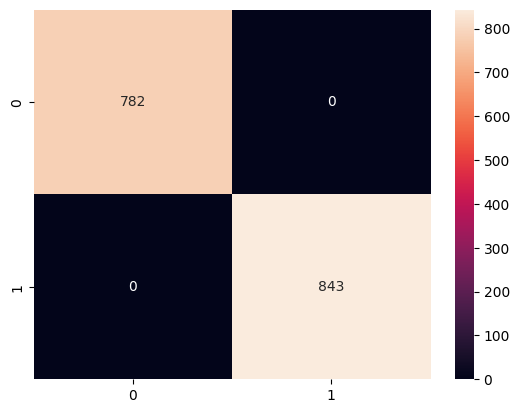

In [4]:
from sklearn.linear_model import LogisticRegression

# create model
logReg = LogisticRegression(solver='saga', penalty=None, max_iter=10000, random_state=42)

# create pipeline
pipe_LogReg = Pipeline([('encoder', encoder),
                        ('model', logReg)])

# train the model
pipe_LogReg.fit(features_train, target_train)

# predict test data
predict_LogReg = pipe_LogReg.predict(features_test)

# Get and display the confusion matrix
conf_matrix = confusion_matrix(target_test, predict_LogReg)
sns.heatmap(conf_matrix, annot=True, fmt='d')

Das unregularisierte Modell hat alle Testdaten perfekt vorhergesagt.
Beeindruckend, aber schauen wir uns dennoch ein regularisiertes Modell zum Vergleich an.
Die besten Parameter sollen mit einer Grid Search gefunden werden. Daher müssen wir verschiedene Parameter vorher definieren.

Das nicht-regularisierte Modell hat uns schon gezeigt, dass alle Pilzsorten perfekt erkannt werden. Aber die regularisierten Modelle
könnten die Sicherheit mit denen die Pilze erkannt werden noch erhöhen. Daher bietet sich der ROC-AUC score als Zielgröße zur Optimierung an.
Außerdem dient der Vergleich zwischen den beiden Modellen auch akademischen Zwecken.

In [5]:
# Define different parameter
cvalues = [0.01, 0.1, 0.5, 1, 5, 10, 50, 1000]
param_grid = {'model__penalty' : ['l1', 'l2'],
              'model__C' : cvalues}

# create pipeline
# Note that regularization needs a scaler
pipe_LogReg_reg = Pipeline([('encoder', encoder),
                        ('scaler', StandardScaler()),
                        ('model', LogisticRegression(solver='saga', 
                                                     max_iter=10000, 
                                                     random_state=42))])

# create the grid search
model_grid = GridSearchCV(estimator=pipe_LogReg_reg,
                          param_grid=param_grid,
                          scoring='roc_auc',
                          cv=5,
                          n_jobs=-1)

# train the model via grid search
model_grid.fit(features_train, target_train)
print('Best parameters: ', model_grid.best_params_)
print('Best score: ', model_grid.best_score_)

Best parameters:  {'model__C': 0.1, 'model__penalty': 'l2'}
Best score:  1.0


<Axes: >

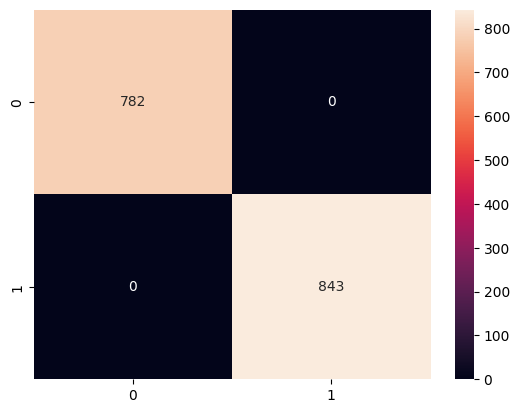

In [6]:
# predict test data
predict_LogReg_reg = model_grid.predict(features_test)

# Get and display the confusion matrix
conf_matrix_reg = confusion_matrix(target_test, predict_LogReg_reg)
sns.heatmap(conf_matrix_reg, annot=True, fmt='d')

# To be continued...